In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import torch
import re
import emoji
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments

In [ ]:
df = pd.read_csv("/content/Tweets.csv")
#EDA
display(df.info())
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

None

(14640, 15)

In [ ]:
df[['airline_sentiment', 'text']].isnull().sum()

,0
airline_sentiment,0
text,0


In [ ]:
df['airline_sentiment'].value_counts()

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


In [ ]:
#keep only text and sentiment because just that what we need
df = df[['text', 'airline_sentiment']]

#keep only positive and negative
df = df[df['airline_sentiment'] != 'neutral']

df['airline_sentiment'].value_counts()

,count
airline_sentiment,
negative,9178
positive,2363


<Axes: xlabel='airline_sentiment', ylabel='count'>

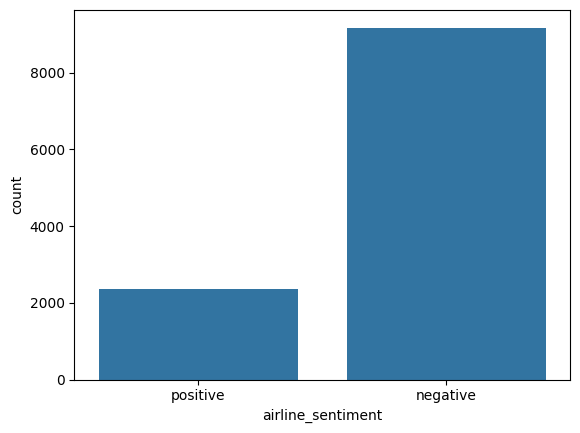

In [ ]:
sns.countplot(x='airline_sentiment', data=df)

In [ ]:
df.shape

(11541, 2)

In [ ]:
df['text_length'] = df['text'].apply(len)
df['text_length'].describe()

,text_length
count,11541.000000
mean,108.242613
std,34.582201
min,12.000000
25%,85.000000
50%,120.000000
75%,137.000000
max,186.000000


In [ ]:
#Encoding negative=0, positive=1
df['labels'] = df['airline_sentiment'].map({'negative': 0, 'positive': 1})

#final dataset
df = df[['text', 'labels']]
display(df.head())
df['labels'].value_counts()

,text,labels
1,@VirginAmerica plus you've added commercials t...,1
3,@VirginAmerica it's really aggressive to blast...,0
4,@VirginAmerica and it's a really big bad thing...,0
5,@VirginAmerica seriously would pay $30 a fligh...,0
6,"@VirginAmerica yes, nearly every time I fly VX...",1


,count
labels,
0,9178
1,2363


In [ ]:
#data split train 80% /test 20%
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'].tolist(),
    df['labels'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['labels']
)

In [ ]:
#preprocessing and data cleaning
slang_dict = {
    "omg": "oh my god",
    "lol": "laughing out loud",
    "u": "you",
    "r": "are",
    "btw": "by the way",
    "idk": "i do not know",
    "smh": "shaking my head",
    "tbh": "to be honest",
}
def expand_slang(text):
    words = text.split()
    new_words = []
    for w in words:
        key = w.lower()
        if key in slang_dict:
            new_words.append(slang_dict[key])
        else:
            new_words.append(w)
    return " ".join(new_words)


def preprocess_tweet(text):
    text = text.lower()
    text = emoji.demojize(text)
    text = expand_slang(text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r"[^a-zA-Z0-9\s:]", "", text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
#apply preprocessing learned from training data
train_texts = [preprocess_tweet(t) for t in train_texts]
test_texts  = [preprocess_tweet(t) for t in test_texts]

In [ ]:
#tokenization
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
test_encodings = tokenizer(test_texts, truncation=True, padding=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
#creating a dataset for BERT training (prepare it for the model)
class TwitterDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key,val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = TwitterDataset(train_encodings, train_labels)
test_dataset = TwitterDataset(test_encodings, test_labels)

In [ ]:
#loading the model
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
#setting training parameters for our model
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    report_to="none"
)

In [ ]:
#how to mesure model performance
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

In [ ]:
#trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Step,Training Loss
500,0.224200
1000,0.127800


TrainOutput(global_step=1154, training_loss=0.1655644816790338, metrics={'train_runtime': 338.7319, 'train_samples_per_second': 54.509, 'train_steps_per_second': 3.407, 'total_flos': 969752429498496.0, 'train_loss': 0.1655644816790338, 'epoch': 2.0})

In [ ]:
print("Evaluation results:", trainer.evaluate())

Evaluation results: {'eval_loss': 0.2073083221912384, 'eval_accuracy': 0.935036812472932, 'eval_f1': 0.8383620689655172, 'eval_runtime': 6.521, 'eval_samples_per_second': 354.084, 'eval_steps_per_second': 22.236, 'epoch': 2.0}


In [ ]:
def predict_sentiment(tweets):
    inputs = tokenizer(tweets, return_tensors="pt", padding=True, truncation=True)
    inputs = {key: val.to(device) for key,val in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.argmax(outputs.logits, dim=1)
    labels = ["negative","positive"]
    return [labels[p.item()] for p in predictions]

In [ ]:
device = torch.device("cpu")
model.to(device)

In [ ]:
new_tweets = ["i caaaaaaan't this is my best triiiiiip ever​", "👌​","i don't really like it "]
new_tweets_clean = [preprocess_tweet(t) for t in new_tweets]
predictions = predict_sentiment(new_tweets_clean)
for t,p in zip(new_tweets, predictions):
    print(t,"→",p)

i caaaaaaan't this is my best triiiiiip for ever​ → positive
👌​ → positive
i don't really like it  → negative
